In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.image as mpimg
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import OrdinalEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Input, BatchNormalization
from tensorflow.keras.regularizers import l2, l1
from tensorflow.keras.optimizers import Adam
import warnings
import pickle
from pathlib import Path
warnings.filterwarnings('ignore')

In [2]:
image = []
target = []
image_test = []
target_test = []

p = Path("/crop")

for f in p.iterdir():
    if f.is_file():
            if ("TR__ovale" in f.name):
                image.append(mpimg.imread(f))
                target.append("ovale")
            elif ("TR__rectangular" in f.name):
                image.append(mpimg.imread(f))
                target.append("rectangular")
            elif ("TR__square" in f.name):
                image.append(mpimg.imread(f))
                target.append("square")
            elif ("TR__round" in f.name):
                image.append(mpimg.imread(f))
                target.append("round")
            elif ("TE__ovale" in f.name):
                image_test.append(mpimg.imread(f))
                target_test.append("ovale")
            elif ("TE__rectangular" in f.name):
                image_test.append(mpimg.imread(f))
                target_test.append("rectangular")
            elif ("TE__square" in f.name):
                image_test.append(mpimg.imread(f))
                target_test.append("square")
            elif("TE__round" in f.name):
                image_test.append(mpimg.imread(f))
                target_test.append("round")

data = {
        "image": image,
        "target": target
        }

data_test = {
        "image": image_test,
        "target": target_test
        }

df = pd.DataFrame(data)
df_test = pd.DataFrame(data_test)

df



,image,target
0,"[[[255, 255, 253], [255, 255, 253], [255, 255,...",ovale
1,"[[[142, 183, 203], [142, 183, 203], [142, 183,...",round
2,"[[[207, 219, 209], [207, 219, 209], [207, 219,...",rectangular
3,"[[[175, 174, 182], [174, 173, 181], [176, 175,...",square
4,"[[[41, 45, 46], [43, 47, 48], [46, 50, 51], [4...",round
...,...,...
994,"[[[70, 58, 44], [70, 58, 44], [70, 58, 44], [7...",rectangular
995,"[[[116, 111, 92], [118, 113, 94], [120, 115, 9...",ovale
996,"[[[237, 238, 240], [236, 237, 239], [237, 238,...",rectangular
997,"[[[40, 33, 17], [40, 33, 17], [40, 33, 17], [4...",rectangular


In [3]:
df_test

,image,target
0,"[[[50, 36, 33], [53, 39, 36], [46, 32, 29], [5...",rectangular
1,"[[[221, 221, 221], [221, 221, 221], [221, 221,...",rectangular
2,"[[[105, 19, 22], [105, 20, 23], [105, 21, 21],...",rectangular
3,"[[[33, 39, 11], [31, 37, 9], [30, 36, 10], [30...",rectangular
4,"[[[110, 117, 127], [111, 118, 128], [115, 122,...",round
...,...,...
245,"[[[183, 169, 120], [178, 166, 118], [160, 147,...",square
246,"[[[52, 52, 64], [52, 52, 64], [53, 53, 65], [5...",square
247,"[[[71, 73, 85], [71, 73, 85], [71, 73, 85], [7...",square
248,"[[[199, 198, 204], [195, 194, 200], [194, 193,...",round


> ### Insight — pemuatan data
>
> 999 gambar train + 250 test = 1.249, sama persis dengan jumlah yang ditulis
> tahap prep. Tidak ada file yang hilang di antara dua notebook.
>
> Split train/test di sini **mengikuti prefiks `TR__`/`TE__`** hasil tahap prep,
> bukan split baru. Karena dedup MD5 sudah dijalankan sebelum prep membagi file,
> tidak ada gambar identik yang bocor dari train ke test — inilah alasan angka
> test di bawah bisa dipercaya sebagai estimasi yang jujur, sekecil apa pun.


In [4]:
X_train, X_val, y_train, y_val = train_test_split(df["image"], df["target"], test_size=0.2, random_state=42)
X_val = np.stack(X_val.to_numpy()).astype(np.uint8)
X_test = np.stack(df_test["image"].to_numpy()).astype(np.uint8)
X_train = np.stack(X_train.to_numpy()).astype(np.uint8)
y_test = df_test["target"]

print('Train Size : ', X_train.shape, X_train.dtype)
print('Val Size   : ', X_val.shape, X_val.dtype)
print('Test Size  : ', X_test.shape, X_test.dtype)
print('Train Size : ', y_train.shape, y_train.dtype)
print('Val Size   : ', y_val.shape, y_val.dtype)
print('Test Size  : ', y_test.shape, y_test.dtype)

Train Size :  (799, 224, 224, 3) uint8
Val Size   :  (200, 224, 224, 3) uint8
Test Size  :  (250, 224, 224, 3) uint8
Train Size :  (799,) object
Val Size   :  (200,) object
Test Size  :  (250,) object


> ### Insight — ukuran split
>
> 799 train / 200 val / 250 test.
>
> Dua catatan yang berpengaruh langsung ke bagian training di bawah:
>
> - `train_test_split` dipanggil **tanpa `stratify=`**, jadi komposisi kelas di
>   val set tidak dijamin mengikuti train. Padahal val set inilah yang dipakai
>   `ModelCheckpoint` untuk memilih model terbaik.
> - Val set hanya 200 gambar. Standard error akurasi pada ukuran segini sekitar
>   ±3,4 poin persen, artinya selisih `val_accuracy` antar-epoch di bawah ~7 poin
>   masih bisa murni kebetulan. Ini bukan keberatan teoretis — lihat insight
>   dinamika training.

In [5]:
encoder_label = OrdinalEncoder(categories=[["ovale", "rectangular", "round", "square"]])
encoder_label.fit(y_train.to_frame())
y_train_encoded = encoder_label.transform(y_train.to_frame())
y_val_encoded = encoder_label.transform(y_val.to_frame())
y_test_encoded = encoder_label.transform(y_test.to_frame())

In [6]:
# Feature Scaling

X_train = X_train / 255.
X_val = X_val / 255.
X_test = X_test / 255.

> ### Insight — encoding label dan skala fitur
>
> `OrdinalEncoder` dipasang dengan urutan kategori eksplisit
> `["ovale", "rectangular", "round", "square"]`, jadi indeks kelas tidak
> bergantung pada urutan kemunculan data. Ini penting karena notebook inference
> memakai daftar `class_names` dengan urutan yang sama — kalau urutannya bergeser,
> prediksi akan tertukar tanpa memunculkan error apa pun.
>
> Encoder di-`fit` hanya pada `y_train`, bukan pada val/test.

In [7]:
# Clear Session
seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

data_augmentation = Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
])

#CNN Iprovement
# Create Sequential API model
model = Sequential()
model.add(Input(shape=(224, 224,3)))
model.add(data_augmentation)
model.add(Conv2D(32, (3,3), padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3,3), padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3,3),padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3),padding="same", activation='relu', kernel_regularizer=l2(5e-5)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(GlobalAveragePooling2D())
model.add(Dropout(0.25))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-3)))
model.add(Dense(4, activation='softmax'))

# Compile
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=Adam(learning_rate=1e-3),
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,828 (1.17 MB)

 Trainable params: 304,932 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

> ### Insight — arsitektur dan kapasitas
>
> Enam lapis konvolusi (32-32-64-64-128-128), BatchNorm di setiap konvolusi,
> `GlobalAveragePooling2D` menggantikan `Flatten`, total **305.828 parameter**
> (304.932 trainable).
>
> Beberapa keputusan di sini :
>
> - GlobalAveragePooling memangkas parameter besar-besaran dibanding `Flatten`,
>   yang dari 28x28x128 akan menghasilkan lapisan padat berisi belasan juta bobot.
> - Augmentasi ditaruh sebagai lapisan **di dalam** model, jadi otomatis aktif
>   saat training dan mati saat `predict` — tidak perlu diurus manual, dan tidak
>   ada risiko lupa mematikannya waktu inference.
> - L2 pada setiap konvolusi, Dropout 0.25 sebelum lapisan padat.


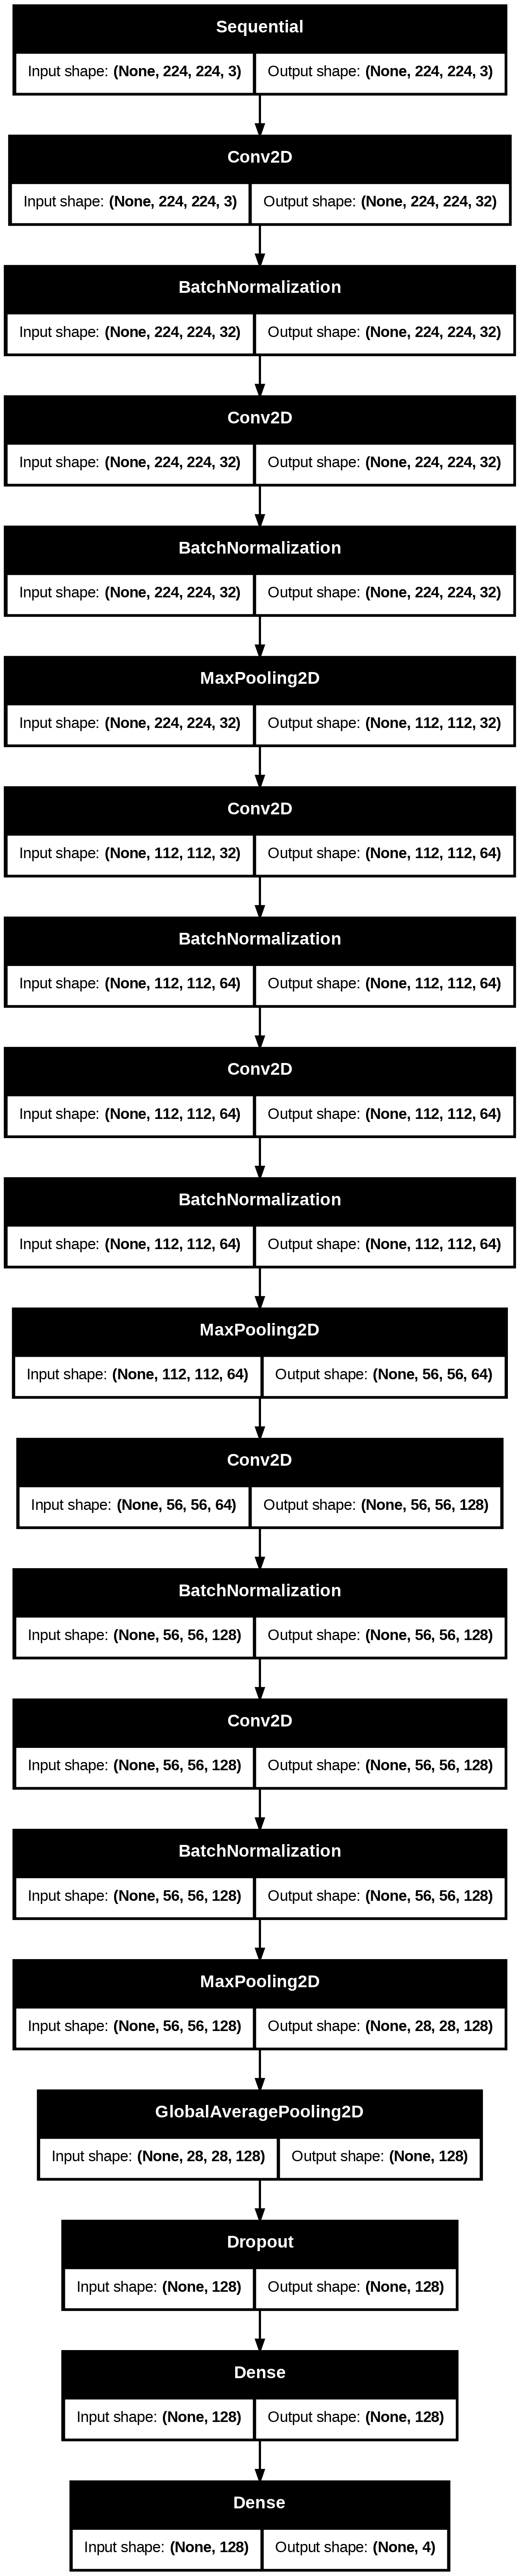

In [8]:
# Display model architecture
tf.keras.utils.plot_model(model, show_shapes=True)

In [9]:
# Train the Model

checkpoint = [tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)]

history_seq1 = model.fit(X_train, y_train_encoded, epochs=200, validation_data=(X_val, y_val_encoded), callbacks=checkpoint)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.2712 - loss: 1.6450
Epoch 1: val_accuracy improved from None to 0.27500, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 438ms/step - accuracy: 0.2841 - loss: 1.6019 - val_accuracy: 0.2750 - val_loss: 1.5534
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.3444 - loss: 1.5046
Epoch 2: val_accuracy improved from 0.27500 to 0.28000, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - accuracy: 0.3442 - loss: 1.5063 - val_accuracy: 0.2800 - val_loss: 1.5651
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.3746 - loss: 1.4576
Epoch 3: val_accuracy did not improve from 0.28000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 261ms/step - accuracy: 0.3792 - loss: 1.4625 - val_accuracy: 0.2800 - val_loss: 1.6225
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - ac

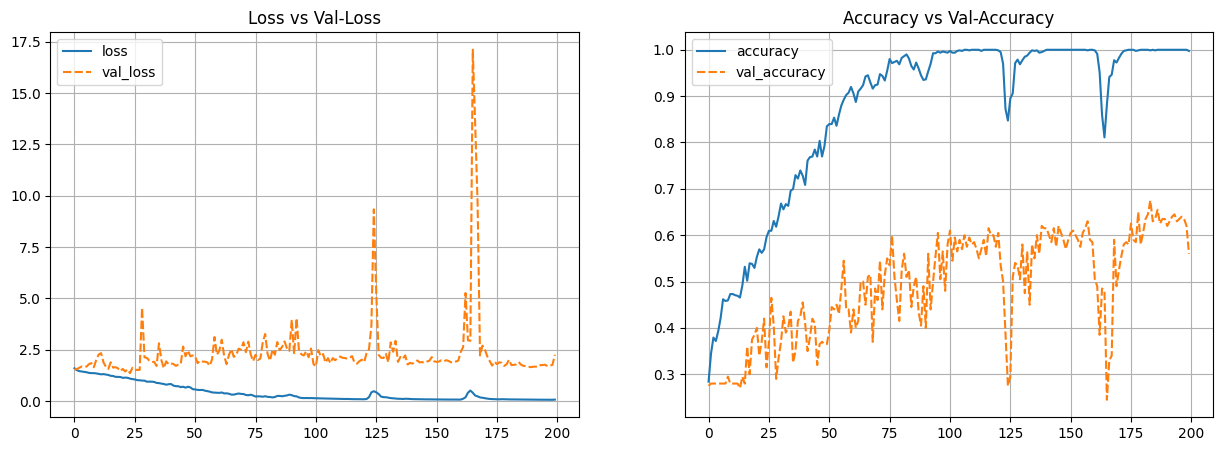

In [10]:
# Plot Training Results

history_seq_df =pd.concat([pd.DataFrame(history_seq1.history)
                           ], ignore_index=True)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_seq_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_seq_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')
plt.show()

> ### Insight — dinamika training
>
> Ringkasan dari log 200 epoch:
>
> | | epoch | train acc | val acc | val loss |
> |---|---|---|---|---|
> | val_loss terbaik | 24 | 0,570 | 0,420 | **1,362** |
> | train acc tembus 0,95 | 75 | 0,955 | 0,550 | 1,950 |
> | val_acc terbaik (dipilih checkpoint) | 184 | 0,999 | **0,675** | 1,792 |
> | epoch terakhir | 200 | 0,998 | 0,560 | 2,260 |
>
> **Model sudah overfit sejak sekitar epoch 25.** Setelah titik itu train loss
> terus turun sampai 0,07 sementara val_loss justru naik dari 1,36 ke 2,26. 175
> epoch terakhir praktis hanya dipakai menghafal data training. Tidak ada
> `EarlyStopping` maupun `ReduceLROnPlateau`, jadi tidak ada yang menghentikannya.
>
> **Checkpoint memilih model pada momen yang meragukan.** `ModelCheckpoint`
> memantau `val_accuracy`, dan nilai terbaiknya (0,675) muncul di epoch 184 —
> saat train accuracy sudah 0,999 dan val_loss sudah 1,79, jauh di dalam wilayah
> overfit. Di 50 epoch terakhir, `val_accuracy` berayun dengan rata-rata 0,577 dan
> simpangan baku 0,088 (terendah 0,245, tertinggi 0,675). Hanya 3 dari 200 epoch
> yang pernah menyentuh 0,65. Dengan val set 200 gambar, angka 0,675 lebih masuk
> akal dibaca sebagai puncak derau daripada sebagai kemampuan model.
>
> Bukti bahwa pembacaan itu benar ada di bagian berikutnya: akurasi test hanya
> 0,58, sekitar 10 poin di bawah `val_accuracy` yang dipakai untuk memilih model.
> Memantau `val_loss` — yang kurvanya jauh lebih halus — akan menghasilkan pilihan
> model yang berbeda, dan kemungkinan besar lebih jujur.

In [11]:
model = tf.keras.models.load_model("best_model.keras")

In [12]:
# Check the performance of test-set
class_names = ["ovale", "rectangular", "round", "square"]
# Get the probability
y_pred_proba = model.predict(X_test)

# Get class with maximum probability
y_pred_test = np.argmax(y_pred_proba, axis=-1)

# Display Classification Report
print(classification_report(y_test_encoded, y_pred_test, target_names=np.array(class_names)))

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step
              precision    recall  f1-score   support

       ovale       0.64      0.55      0.59        66
 rectangular       0.46      0.66      0.54        58
       round       0.70      0.61      0.65        64
      square       0.59      0.53      0.56        62

    accuracy                           0.58       250
   macro avg       0.60      0.59      0.59       250
weighted avg       0.60      0.58      0.59       250



> ### Insight — hasil di test set
>
> Akurasi **0,58** pada 250 gambar test, dengan baseline tebak-acak 0,25 untuk
> empat kelas. Model jelas mempelajari sesuatu yang nyata, tapi belum layak pakai.
>
> | kelas | precision | recall | f1 | support |
> |---|---|---|---|---|
> | ovale | 0,64 | 0,55 | 0,59 | 66 |
> | rectangular | 0,46 | 0,66 | 0,54 | 58 |
> | round | 0,70 | 0,61 | 0,65 | 64 |
> | square | 0,59 | 0,53 | 0,56 | 62 |
>
> Polanya konsisten dan cukup memberi tahu: **`rectangular` punya recall tertinggi
> (0,66) tapi precision terendah (0,46)** — model terlalu sering menebak
> rectangular, dan lebih dari separuh tebakan itu salah. Tiga kelas lainnya
> semuanya punya recall di bawah precision, artinya mereka kehilangan sampel ke
> arah rectangular. Jadi error-nya tidak menyebar merata; ada satu kelas yang
> menjadi keranjang tempat model membuang kasus yang tidak diyakininya.
>
> `round` paling mudah dikenali (f1 0,65). Ini masuk akal: rasio lebar-tinggi
> wajah bulat paling berbeda dari tiga kelas lain — dan rasio itulah yang sengaja
> dijaga lewat crop persegi di tahap prep.
>
> Support antar kelas cukup seimbang (58-66), jadi angka akurasi keseluruhan tidak
> terdistorsi oleh ketimpangan kelas.

In [ ]:
# Model is saved to desired folder
with open("files/model.pkl", 'wb') as file_1:
  pickle.dump(model, file_1)

> ### Insight — penyimpanan model
>
> Model yang disimpan di sini adalah `best_model.keras` yang baru dimuat ulang di
> sel sebelumnya, bukan model di akhir epoch 200. Urutannya sudah benar.
>
